In [1]:
import pandas as pd

cohort = pd.read_csv('cohort_retention.csv')
rfm = pd.read_csv('rfm_segments.csv')
funnel = pd.read_csv('funnel.csv')

print("Cohort shape:", cohort.shape)
print("RFM shape:", rfm.shape)
print("Funnel shape:", funnel.shape)

print("\nCohort columns:", cohort.columns.tolist())
print("RFM columns:", rfm.columns.tolist())
print("Funnel columns:", funnel.columns.tolist())

Cohort shape: (219, 5)
RFM shape: (5, 5)
Funnel shape: (1, 7)

Cohort columns: ['cohort_month', 'month_number', 'cohort_size', 'retained_customers', 'retention_pct']
RFM columns: ['segment', 'customer_count', 'pct', 'avg_spend', 'avg_recency']
Funnel columns: ['total_orders_placed', 'total_orders_approved', 'pct_drop_approval', 'total_orders_dispatched', 'pct_drop_distribution', 'total_orders_delivered', 'pct_drop_delivery']


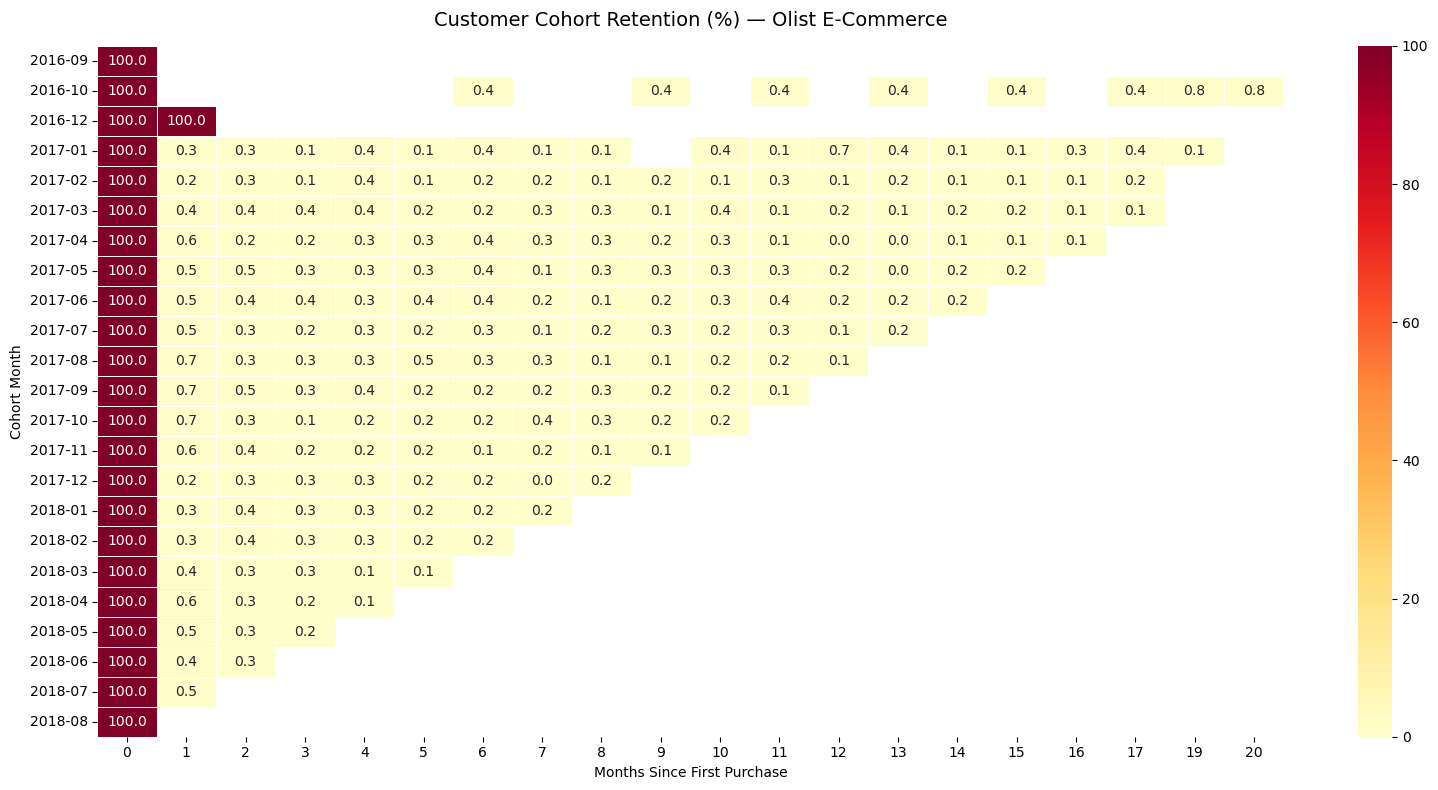

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert cohort_month to just year-month string for cleaner labels
cohort['cohort_month'] = pd.to_datetime(cohort['cohort_month']).dt.strftime('%Y-%m')

# Pivot to wide format - rows = cohort months, columns = month numbers
cohort_pivot = cohort.pivot_table(
    index='cohort_month', 
    columns='month_number', 
    values='retention_pct'
)

# Plot
plt.figure(figsize=(16, 8))
sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    mask=cohort_pivot.isnull()
)
plt.title('Customer Cohort Retention (%) — Olist E-Commerce', fontsize=14, pad=15)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

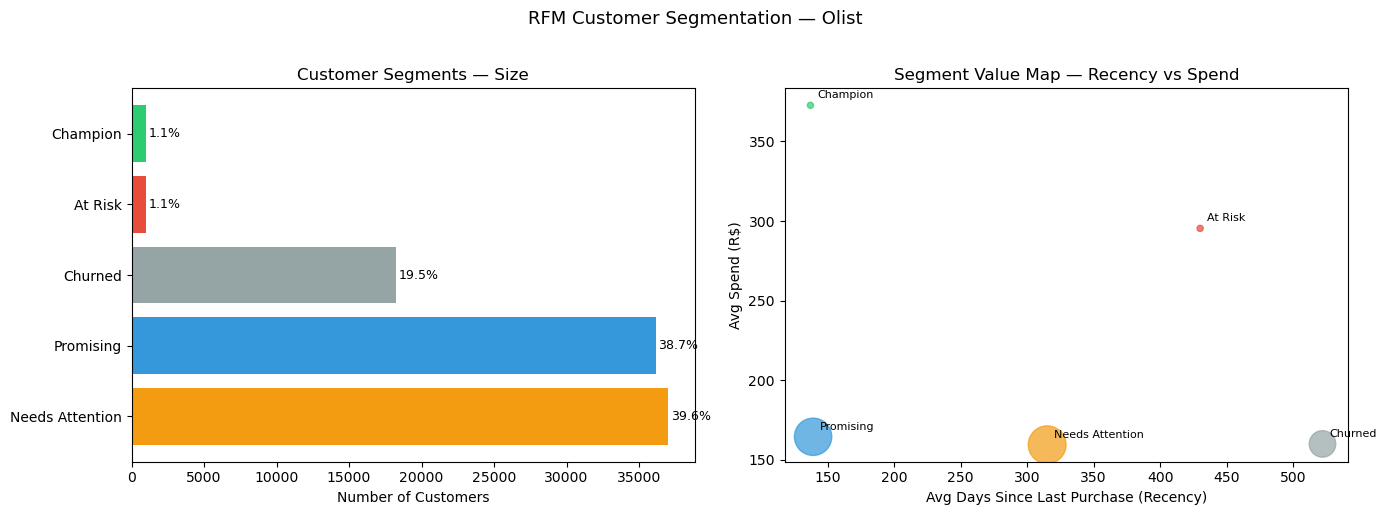

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Segment sizes
colors = {
    'Champion': '#2ecc71',
    'At Risk': '#e74c3c', 
    'Promising': '#3498db',
    'Churned': '#95a5a6',
    'Needs Attention': '#f39c12'
}
bar_colors = [colors[seg] for seg in rfm['segment']]

ax1.barh(rfm['segment'], rfm['customer_count'], color=bar_colors)
ax1.set_xlabel('Number of Customers')
ax1.set_title('Customer Segments — Size')
for i, (count, pct) in enumerate(zip(rfm['customer_count'], rfm['pct'])):
    ax1.text(count + 200, i, f'{pct}%', va='center', fontsize=9)

# Chart 2 - Avg spend vs avg recency by segment
scatter_colors = [colors[seg] for seg in rfm['segment']]
ax2.scatter(rfm['avg_recency'], rfm['avg_spend'], 
            c=scatter_colors, s=rfm['customer_count']/50, alpha=0.7)
for i, row in rfm.iterrows():
    ax2.annotate(row['segment'], 
                (row['avg_recency'], row['avg_spend']),
                textcoords='offset points', xytext=(5,5), fontsize=8)
ax2.set_xlabel('Avg Days Since Last Purchase (Recency)')
ax2.set_ylabel('Avg Spend (R$)')
ax2.set_title('Segment Value Map — Recency vs Spend')

plt.suptitle('RFM Customer Segmentation — Olist', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

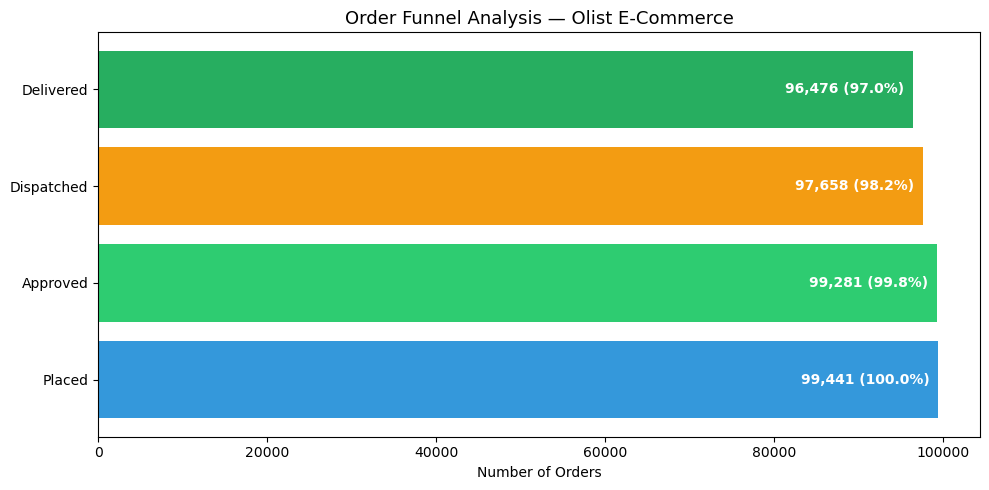

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

stages = ['Placed', 'Approved', 'Dispatched', 'Delivered']
values = [
    funnel['total_orders_placed'].values[0],
    funnel['total_orders_approved'].values[0],
    funnel['total_orders_dispatched'].values[0],
    funnel['total_orders_delivered'].values[0]
]

colors = ['#3498db', '#2ecc71', '#f39c12', '#27ae60']
bars = ax.barh(stages, values, color=colors)

for bar, val in zip(bars, values):
    pct = val / values[0] * 100
    ax.text(bar.get_width() - 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', ha='right', 
            color='white', fontweight='bold')

ax.set_xlabel('Number of Orders')
ax.set_title('Order Funnel Analysis — Olist E-Commerce', fontsize=13)
ax.set_xlim(0, values[0] * 1.05)
plt.tight_layout()
plt.savefig('funnel.png', dpi=150, bbox_inches='tight')
plt.show()